# Component 2 — Quantum Data Generation
### AI Design of Quantum Processors · Mondragon-Shem Quantum Group (UIC)
**Author:** Marcos Sandoval Lucas

**Goal of this component.** Compute the *quantum* properties of the same harmonic oscillator — its allowed energies and how its states evolve — both with exact formulas (our answer key) and with **QuTiP**. These quantum results are the **prediction targets** for the machine-learning model in Component 3.

**What you will do here**
- **Task 1:** build the quantum operators, visualize them, and compute the energy spectrum.
- **Task 2:** evolve three quantum states in time, draw them in phase space with the **Wigner function**, animate them, and compare to classical motion.
- **Task 3:** move from the ideal oscillator to a **real qubit** — build the fluxonium with `scqubits`, find its double-well spectrum, and evolve wave packets against the matching classical motion.

Tasks 1–2 are the textbook oscillator, where every number has an exact formula to check against. Task 3 spends that confidence on hardware that has no closed-form answer.

> **The big shift from Component 1.** Classically the oscillator is a *point* at a definite $(x,p)$ on an ellipse. Quantum-mechanically you can never know $x$ and $p$ exactly at once, so the "point" becomes a *fuzzy blob*, and energy comes only in *fixed steps*.

> **Sources & conventions.** This notebook uses the conventions of Essler's *Lecture Notes for Quantum Mechanics* (your group's text); Essler equation numbers are cited at the relevant steps below. **Why this matters for hardware:** these are the energy levels of a superconducting **LC circuit**, the seed of a real qubit (see study guide, Part 7).

## Setup and conventions
We continue in **natural units** $\hbar = m = \omega = 1$. The infinite quantum oscillator is *truncated* to the lowest $N$ energy levels so every operator becomes a finite $N\times N$ matrix.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import destroy, basis, coherent, sesolve, wigner   # only what this notebook uses
from oscillator import setup     # shared helper module (lives in shared/, importable anywhere)

# --- Natural units: hbar = m = omega = 1 ---
hbar = 1.0; m = 1.0; omega = 1.0
N = 30                       # number of energy levels kept (Hilbert-space truncation)

setup()       # group plot style + output routing (figures/ data/ movies/) in one call
print("QuTiP", qutip.__version__, "| truncation N =", N, "| units: hbar=m=omega=1")

Setup ready: group plot style applied, outputs route to figures/ data/ movies/.
QuTiP 5.3.0 | truncation N = 30 | units: hbar=m=omega=1


In [2]:
qutip.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.3.0
Numpy Version:      2.4.6
Scipy Version:      1.17.1
Cython Version:     None
Matplotlib Version: 3.10.9
Python Version:     3.14.4
Number of CPUs:     20
BLAS Info:          scipy-openblas
INTEL MKL Ext:      None
Platform Info:      Windows (AMD64)
Installation path:  C:\Users\galli\quantum-research\.venv\Lib\site-packages\qutip

Installed QuTiP family packages
-------------------------------

No QuTiP family packages installed.


---
# Task 1 — Operators and the energy spectrum

### (a) Building the quantum operators
We start from the **annihilation operator** $\hat a$ (lowers energy by one rung) and its partner the **creation operator** $\hat a^\dagger$ (raises by one rung). Everything else is built from them:
$$\hat x=\sqrt{\tfrac{\hbar}{2m\omega}}\,(\hat a+\hat a^\dagger),\qquad
\hat p=-i\sqrt{\tfrac{\hbar m\omega}{2}}\,(\hat a-\hat a^\dagger),\qquad
\hat H=\frac{\hat p^2}{2m}+\tfrac12 m\omega^2\hat x^2=\hbar\omega\!\left(\hat a^\dagger\hat a+\tfrac12\right).$$
In natural units the prefactors are both $1/\sqrt2$.

*Essler reference: these definitions are his eq. 230, written with a length scale $\ell=\sqrt{\hbar/2m\omega}$ so $\hat x=\ell(\hat a+\hat a^\dagger)$; in natural units $\ell=1/\sqrt2$. Commutator $[\hat a,\hat a^\dagger]=1$ is eq. 231; $\hat H=\hbar\omega(\hat a^\dagger\hat a+\tfrac12)$ is eq. 233.*

In [3]:
# Ladder operators (the building blocks). destroy(N) is the annihilation operator a.
a = destroy(N)
adag = a.dag()                          # creation operator a-dagger

# Position and momentum operators from the ladder operators (natural units -> 1/sqrt(2)).
x_op = (a + adag) / np.sqrt(2)
p_op = -1j * (a - adag) / np.sqrt(2)

# Quantum Hamiltonian, built two equivalent ways (we verify they match).
H = p_op**2 / (2*m) + 0.5 * m * omega**2 * x_op**2
H_ladder = hbar * omega * (adag * a + 0.5)
# The two forms agree on the low-energy block; they differ only at the very top
# row/column because the truncated x_op, p_op lose matrix elements there (a pure
# boundary artifact of the finite N).
block = N // 2
diff_low = np.abs((H - H_ladder).full()[:block, :block]).max()
print(f"Difference on the low-energy block = {diff_low:.2e}  (~0 -> the algebra checks out)")
print(f"Full-matrix difference = {float((H - H_ladder).norm()):.2f}  (nonzero only at the truncation edge)")
print("Hamiltonian is", H.shape[0], "x", H.shape[1])

Difference on the low-energy block = 0.00e+00  (~0 -> the algebra checks out)
Full-matrix difference = 15.00  (nonzero only at the truncation edge)
Hamiltonian is 30 x 30


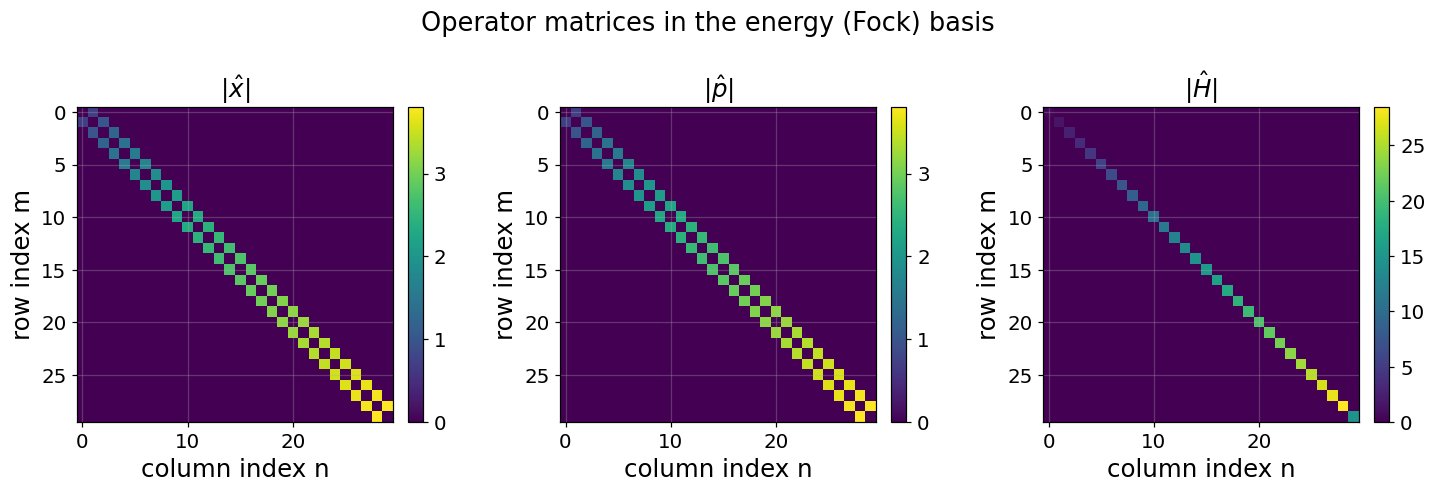

In [4]:
# Visualize the absolute values of the operator matrix elements.
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
for ax, op, name in zip(axes, [x_op, p_op, H], [r"$|\hat x|$", r"$|\hat p|$", r"$|\hat H|$"]):
    im = ax.imshow(np.abs(op.full()), cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("column index n")
    ax.set_ylabel("row index m")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Operator matrices in the energy (Fock) basis", y=1.02)
plt.tight_layout()
plt.savefig("fig_c2_operator_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Absolute values of the matrix elements of $\hat x$, $\hat p$, and $\hat H$ in the energy basis. $\hat H$ is purely **diagonal** because it is written in its own eigenbasis (each level has a definite energy). $\hat x$ and $\hat p$ have nonzero entries only on the first off-diagonals — they connect a level only to its immediate neighbors, which is the ladder structure ("selection rules") made visible.*


### (b) The energy spectrum
The allowed energies are the **eigenvalues** of $\hat H$. The exact answer is
$$E_n=\hbar\omega\left(n+\tfrac12\right),\quad n=0,1,2,\dots$$
We compute the eigenvalues numerically and overlay this exact line.

*Essler reference: spectrum $E_n=\hbar\omega(n+\tfrac12)$ is eq. 246; the zero-point energy $E_0=\tfrac12\hbar\omega$ is eq. 244.*

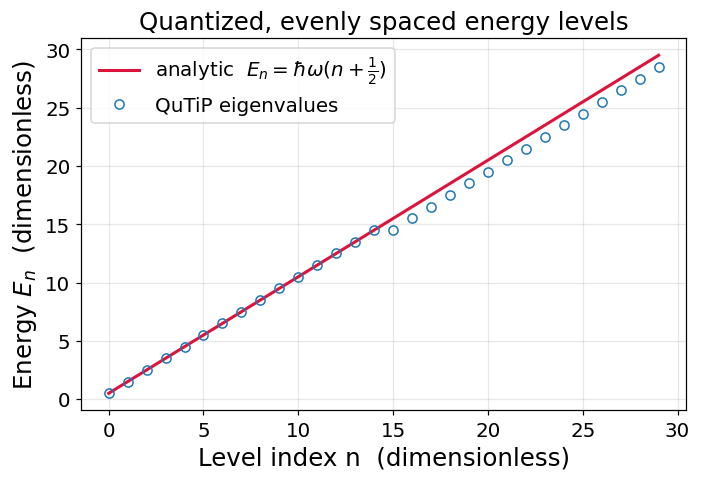

In [5]:
# Numerical eigenvalues of the Hamiltonian matrix.
eigvals = H.eigenenergies()
n_index = np.arange(N)
analytic = hbar * omega * (n_index + 0.5)   # exact formula E_n = n + 1/2

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.plot(n_index, analytic, "-", color="crimson", lw=2,
        label=r"analytic  $E_n=\hbar\omega(n+\frac{1}{2})$")
ax.plot(n_index, eigvals, "o", color="#1f77b4", ms=6, mfc="none",
        label="QuTiP eigenvalues")
ax.set_xlabel("Level index n  (dimensionless)")
ax.set_ylabel("Energy $E_n$  (dimensionless)")
ax.set_title("Quantized, evenly spaced energy levels")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c2_energy_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# --- Sanity checks against the exact formula ---
print(f"Ground-state energy E_0 = {eigvals[0]:.6f}  (expected 0.5 -> zero-point energy)")
spacing = np.diff(eigvals[:6])
print(f"Spacing between low levels = {np.round(spacing, 6)}  (expected all 1.0)")
# Only the LOWER part of the spectrum is reliable: building H from truncated x,p
# loses matrix elements near the top level, so high-n eigenvalues drift. This is
# the expected signature of a finite Hilbert space -> we check the trustworthy region.
n_reliable = N // 2                      # conservative: lower half is exact
max_err_low = np.max(np.abs(eigvals[:n_reliable] - analytic[:n_reliable]))
print(f"Max error over the lowest {n_reliable} levels = {max_err_low:.2e}")
assert abs(eigvals[0] - 0.5) < 1e-6, "ground state should be the zero-point energy 1/2"
assert max_err_low < 1e-6, "low spectrum should match exactly"
print("PASS: low spectrum matches the exact formula -> operators are correct.")
print("(High-n levels drift on purpose: that is truncation. Increase N to push it up.)")

Ground-state energy E_0 = 0.500000  (expected 0.5 -> zero-point energy)
Spacing between low levels = [1. 1. 1. 1. 1.]  (expected all 1.0)
Max error over the lowest 15 levels = 5.33e-15
PASS: low spectrum matches the exact formula -> operators are correct.
(High-n levels drift on purpose: that is truncation. Increase N to push it up.)


### Convergence check — how truncation $N$ limits the trustworthy spectrum
The handout's roadmap stresses: *always check convergence in $N$.* Because $\hat x,\hat p$ are truncated, the highest eigenvalues are wrong. Increasing $N$ pushes the trustworthy range higher. We demonstrate this.


N= 10: lowest  5 levels are exact (error < 1e-6)
N= 30: lowest 15 levels are exact (error < 1e-6)
N= 50: lowest 25 levels are exact (error < 1e-6)


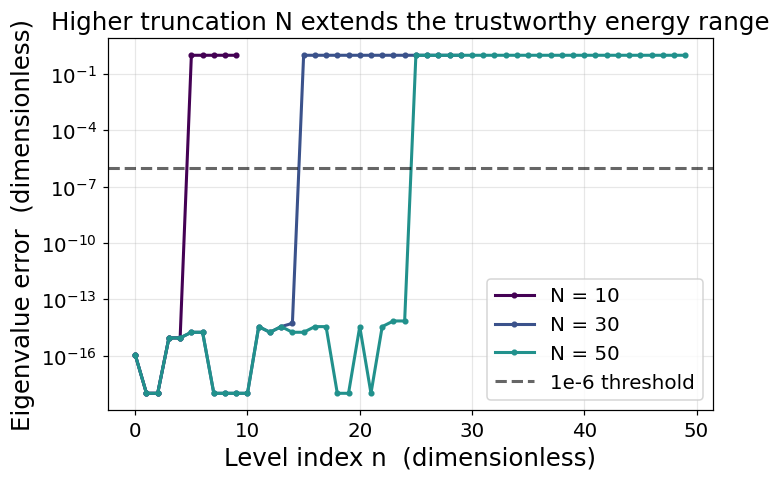

In [7]:
# Compare how many low levels are exact for different truncations N.
fig, ax = plt.subplots(figsize=(6.8, 4.6))
for N_test in [10, 30, 50]:
    a_t = destroy(N_test)
    x_t = (a_t + a_t.dag()) / np.sqrt(2)
    p_t = -1j * (a_t - a_t.dag()) / np.sqrt(2)
    H_t = p_t**2 / 2 + x_t**2 / 2
    err_t = np.abs(H_t.eigenenergies() - (np.arange(N_test) + 0.5))
    n_good = int(np.argmax(err_t > 1e-6)) if np.any(err_t > 1e-6) else N_test
    print(f"N={N_test:3d}: lowest {n_good:2d} levels are exact (error < 1e-6)")
    ax.semilogy(np.arange(N_test), err_t + 1e-18, marker="o", ms=3, label=f"N = {N_test}")
ax.axhline(1e-6, ls="--", color="k", alpha=0.6, label="1e-6 threshold")
ax.set_xlabel("Level index n  (dimensionless)")
ax.set_ylabel("Eigenvalue error  (dimensionless)")
ax.set_title("Higher truncation N extends the trustworthy energy range")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_c2_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Eigenvalue error vs. level index for three truncations. Each curve stays at machine-zero for low $n$, then blows up near the top of its truncated space. Larger $N$ keeps more levels accurate — so for any quantity you compute, increase $N$ until the result stops changing. This is the standard convergence discipline for truncated quantum simulations.*


### (c) What changed (and what stayed the same) going classical → quantum
**Stayed the same:** the *form* of the energy — kinetic plus a quadratic potential — and the natural frequency $\omega$. The quantum Hamiltonian is the classical one with $x,p$ promoted to operators.

**Changed:**
1. **Energy is now discrete.** Classically any energy $E\ge 0$ is allowed (any size circle). Quantum-mechanically only $E_n=\hbar\omega(n+\tfrac12)$ are allowed — a ladder of evenly spaced rungs.
2. **There is a nonzero floor.** The lowest energy is $\tfrac12\hbar\omega$, not $0$: the **zero-point energy**. The quantum oscillator can never sit perfectly still, because that would mean knowing $x$ and $p$ exactly at once (forbidden by $[\hat x,\hat p]=i\hbar$).
3. **State, not point.** The classical point $(x,p)$ becomes a spread-out quantum state. We visualize that next.


---
# Task 2 — State dynamics and phase space

### (a) Three initial states, evolved with the Schrödinger equation
Quantum time evolution obeys $i\hbar\,\frac{d}{dt}|\psi(t)\rangle=\hat H|\psi(t)\rangle$. QuTiP's `sesolve` integrates this — it is the quantum twin of `solve_ivp`. We evolve three states, each highlighting a different facet of quantum behavior:
1. **Energy eigenstate (Fock) $|1\rangle$** — a state of one definite energy; stationary, with zero average position/momentum for all time.
2. **Superposition $(|0\rangle+|1\rangle)/\sqrt2$** — two energies at once; interference makes the average position oscillate like a pendulum.
3. **Coherent state $|\alpha\rangle$** — the most classical-like state; a compact blob that orbits the origin holding its shape.

*Essler reference: coherent states are his "Aside 4" (eqs. 281–289), defined by $\hat a|\alpha\rangle=\alpha|\alpha\rangle$. That $\langle\hat x\rangle(t)$ oscillates at $\omega$ for the superposition is his §6.3; Ehrenfest's theorem is his §4.1.*

In [8]:
# Define the three initial states.
psi_fock  = basis(N, 1)                                   # |1>
psi_super = (basis(N, 0) + basis(N, 1)).unit()           # (|0>+|1>)/sqrt(2), .unit() normalizes
alpha = 1.5                                               # coherent-state amplitude (real here)
psi_coh   = coherent(N, alpha)                            # |alpha>

states = {"Fock |1>": psi_fock, "Superposition (|0>+|1>)/sqrt2": psi_super,
          f"Coherent |a={alpha}>": psi_coh}

# Time grid: one full classical period T = 2*pi/omega.
T = 2 * np.pi / omega
tlist = np.linspace(0, T, 200)

# Evolve each state; store the full state at every time AND the expectation values <x>,<p>.
results = {}
for name, psi0 in states.items():
    res = sesolve(H, psi0, tlist, e_ops=[x_op, p_op],
                  options={"store_states": True})
    results[name] = res
    print(f"Evolved {name}: stored {len(res.states)} states.")


Evolved Fock |1>: stored 200 states.
Evolved Superposition (|0>+|1>)/sqrt2: stored 200 states.
Evolved Coherent |a=1.5>: stored 200 states.


### (b) Wigner function at $t=0$
The **Wigner function** $W(x,p)$ draws a quantum state in the same phase-space plane we used classically. Its signature feature: it can go **negative**, and negativity has no classical explanation — it is the fingerprint of "genuinely quantum."

*(QuTiP's default Wigner convention with $g=\sqrt2$ uses exactly our $\hat x=(\hat a+\hat a^\dagger)/\sqrt2$ and $\hat p=-i(\hat a-\hat a^\dagger)/\sqrt2$, so the axes match our operators directly.)*

*Note on sources: the Wigner function is **not** in Essler's notes — it comes from your project handout. Essler compares quantum vs. classical using the position density $|\psi_n(x)|^2$ instead (his §6.4). We use Wigner because it lives in the same $(x,p)$ plane as the classical data.*

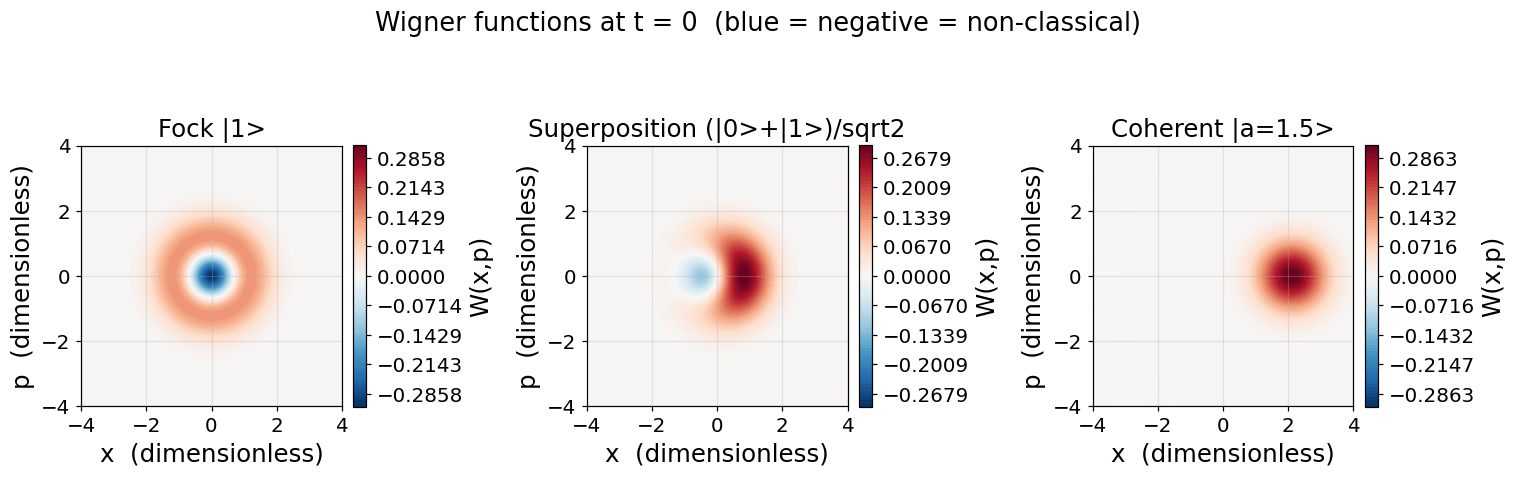

In [9]:
# Phase-space grid for the Wigner function.
xvec = np.linspace(-4, 4, 200)
pvec = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (name, psi0) in zip(axes, states.items()):
    W = wigner(psi0, xvec, pvec)                  # quasi-probability on the (x,p) grid
    wmax = np.abs(W).max()                         # symmetric scale so 0 sits at white
    # Explicit level array, NOT levels=80 + vmin/vmax: given an integer `levels`,
    # contourf picks levels from the data's own range and ignores vmin/vmax, so
    # white would not actually land on W = 0.
    cf = ax.contourf(xvec, pvec, W, levels=np.linspace(-wmax, wmax, 81), cmap="RdBu_r")
    ax.set_title(name); ax.set_xlabel("x  (dimensionless)")
    ax.set_ylabel("p  (dimensionless)"); ax.set_aspect("equal")
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label="W(x,p)")
fig.suptitle("Wigner functions at t = 0  (blue = negative = non-classical)", y=1.03)
plt.tight_layout()
plt.savefig("fig_c2_wigner_t0.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Wigner functions at $t=0$. The **coherent state** is a single positive Gaussian offset from the origin — no negativity, the most classical state. The **Fock state $|1\rangle$** is a ring with a deep **negative** crater at the center — strongly non-classical. The **superposition** shows two lobes separated by alternating positive/negative **interference fringes** — proof the system is in a true coherent superposition, not a random mixture.*

A diverging colormap (`RdBu_r`) is used here on purpose: the data is *signed*, so we need a map that distinguishes positive (red) from negative (blue) with white at zero. (Sequential maps like `viridis` are reserved for the unsigned classical energy.)


### (c) Animated Wigner dynamics
We now animate each state over one period with a **fixed color scale per movie**, so changes in shape and sign are meaningful. For the harmonic oscillator the Wigner function simply **rotates rigidly** about the origin — mirroring the classical flow.


Saved movies/wigner_fock.gif
Saved movies/wigner_superposition.gif
Saved movies/wigner_coherent.gif
Fock |1>


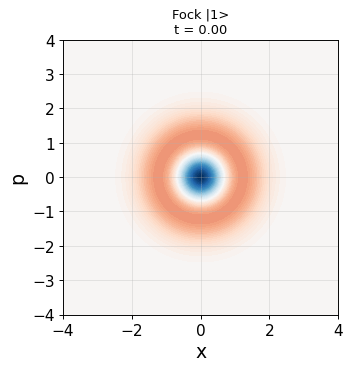

Superposition (|0>+|1>)/sqrt2


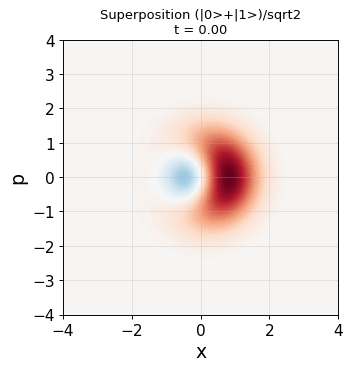

Coherent |a=1.5>


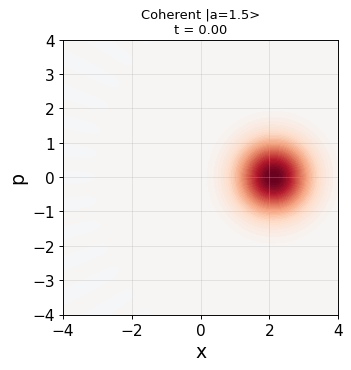

In [10]:
# Build an animated GIF of the Wigner evolution for each state.
# The heavy lifting (compute frames, fixed color scale, render, encode) lives in
# shared/oscillator.py -> wigner_gif(); here we just call it for each state.
from oscillator import wigner_gif
from IPython.display import Image as IPyImage, display

gif_paths = {}
for name, res in results.items():
    safe = name.split()[0].lower()          # 'fock', 'superposition', 'coherent'
    path = wigner_gif(res.states, tlist, f"movies/wigner_{safe}.gif",
                      xvec=xvec, pvec=pvec, title=name)
    gif_paths[name] = path
    print("Saved", path)

# Display the three animations inline.
for name, path in gif_paths.items():
    print(name)
    display(IPyImage(filename=path))

**What you should see.** The coherent blob orbits the origin like a classical particle. The Fock ring rotates onto itself — it looks unchanged, confirming it is a *stationary* state. The superposition's fringes rotate, sweeping the lobes back and forth, which is exactly the oscillation of $\langle\hat x\rangle$ we quantify next.


### (d) Expectation values vs. the classical trajectory
For each quantum state we plot the average phase-space path $\big(\langle\hat x\rangle(t),\langle\hat p\rangle(t)\big)$ and overlay the **classical** trajectory started from the same point $(x_0,p_0)=(\langle\hat x\rangle(0),\langle\hat p\rangle(0))$.


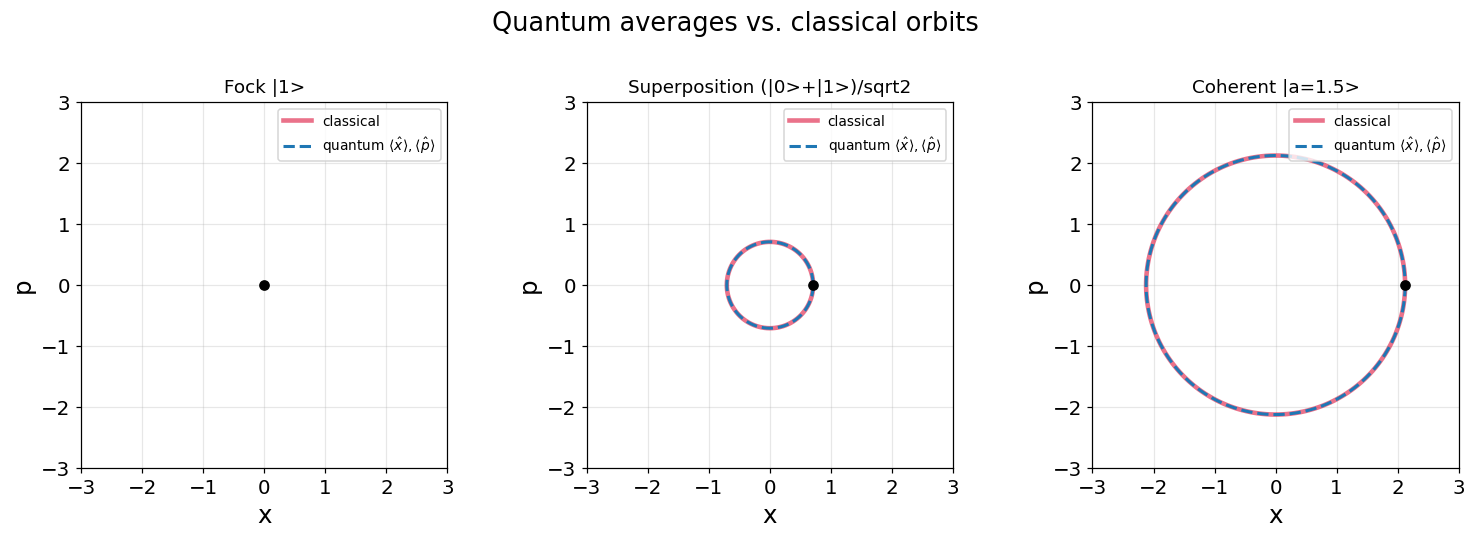

In [11]:
from scipy.integrate import solve_ivp
def classical_rhs(t, s):                 # same Hamilton's equations as Component 1
    x, p = s
    return [p/m, -m*omega**2*x]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (name, res) in zip(axes, results.items()):
    xq, pq = res.expect[0], res.expect[1]            # quantum averages over time
    x0, p0 = xq[0], pq[0]                             # matching classical start point
    csol = solve_ivp(classical_rhs, (0, T), [x0, p0],
                     t_eval=tlist, rtol=1e-9, atol=1e-9)
    ax.plot(csol.y[0], csol.y[1], "-", color="crimson", lw=3, alpha=0.6,
            label="classical")
    ax.plot(xq, pq, "--", color="#1f77b4", lw=2, label=r"quantum $\langle\hat x\rangle,\langle\hat p\rangle$")
    ax.plot(x0, p0, "ko", ms=6)
    ax.set_title(name, fontsize=12); ax.set_xlabel("x"); ax.set_ylabel("p")
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
fig.suptitle(r"Quantum averages vs. classical orbits", y=1.03)
plt.tight_layout()
plt.savefig("fig_c2_expectation_vs_classical.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption & discussion.** *For the **coherent state**, the quantum average traces the classical circle almost perfectly — a visual confirmation of **Ehrenfest's theorem** (quantum averages obey classical equations of motion). For the **Fock state**, $\langle\hat x\rangle=\langle\hat p\rangle=0$ for all time, so it sits as a single point at the origin — the average completely hides the ringed, spread-out structure we saw in the Wigner plot. For the **superposition**, the average traces a smaller circle driven by interference.*

**The key limitation (what Task 2d asks you to reflect on):** reducing a state to its averages $(\langle\hat x\rangle,\langle\hat p\rangle)$ throws away the variance (the blob's spread), the uncertainty, and any interference. The average can look perfectly classical *precisely because* averaging erases the quantum richness. That is exactly why the Wigner function — which keeps all of it — is the representation we hand to the machine-learning model.


### (e) One-page reflection — what each representation tells you

**Energy contours (Component 1).** The classical phase-space map: closed constant-energy curves. They tell you *which states share an energy* and that classical motion is confined to one curve. Pure geometry of conservation, no quantum content.

**Operator matrices ($\hat x,\hat p,\hat H$).** The quantum bookkeeping. The diagonal $\hat H$ shows energy is well-defined per level; the off-diagonal $\hat x,\hat p$ show that position and momentum only connect neighboring levels. This is where non-commutativity ($[\hat x,\hat p]=i\hbar$) and the ladder structure live.

**Eigenvalues.** The measurable energies. They reveal quantization (discrete rungs), even spacing ($\hbar\omega$), and the zero-point energy ($\tfrac12\hbar\omega$) — the cleanest, most quantitative break from classical physics, and our primary sanity check.

**Wigner functions.** The complete quantum state drawn in the *same* phase space as the classical picture. Positivity ≈ classical-like; negativity = certainly quantum. Coherent → positive Gaussian; Fock → negative rings; superposition → interference fringes. This is the representation that carries *all* the quantum information into a classical-looking coordinate system — the bridge to Component 3.

**Expectation-value phase-space plots.** The averages only. They show when quantum motion mimics classical motion (Ehrenfest, best for coherent states) but discard spread, uncertainty, and interference. Useful for intuition, insufficient as a full description.

**Bottom line.** Energy contours and eigenvalues fix the *skeleton* (what's allowed); the Wigner function provides the *flesh* (the full state, including the non-classical parts); expectation values are a *shadow* of that full state. Component 3 will learn to predict the rich quantum targets (especially Wigner data) from the cheap classical inputs.


---
## Tasks 1–2 — takeaways
- Built $\hat x,\hat p,\hat H$ from ladder operators in QuTiP; verified the Hamiltonian two ways.
- Energy spectrum is discrete and evenly spaced with a zero-point floor $\tfrac12\hbar\omega$; the low spectrum matched the exact formula (sanity check passed).
- Evolved three states with `sesolve`; visualized them with Wigner functions and animations.
- Confirmed Ehrenfest's theorem for the coherent state and discussed the information lost in averages.
- **Outputs for Component 3:** spectrum, expectation trajectories, and Wigner data + the saved figures and `movies/`.

- **Hardware link:** these evenly-spaced levels are exactly those of a superconducting LC circuit. Because they are *equally* spaced, a pure oscillator cannot be a qubit; a Josephson junction makes them *unequal* (a transmon), isolating two levels. See study guide Part 7.

*That last point is exactly why Task 3 exists: the perfect oscillator can never be a qubit, so we now build one that can — the fluxonium.*

---
# Task 3 — Fluxonium: wave packets and phase–charge dynamics

A **fluxonium** is a real superconducting qubit: a Josephson junction shunted by a large inductor. Its quantum Hamiltonian is
$$\hat H = 4E_C\,\hat n^2 + \tfrac12 E_L\hat\varphi^{\,2} - E_J\cos(\hat\varphi+\varphi_{ext}),$$
with charging energy $E_C$, inductive energy $E_L$, Josephson energy $E_J$, and external flux $\varphi_{ext}$.

> **Which coordinate?** This is `scqubits`' convention, and I follow it everywhere below. The inductive term is centred on $\varphi=0$, so at half flux the two wells sit at $\varphi\approx\pm2.85$ and **$\varphi=0$ is the top of the barrier**. The same physics can be written $\tfrac12 E_L(\varphi-\varphi_{ext})^2-E_J\cos\varphi$, but that is a *different coordinate*, shifted by $\varphi_{ext}$ — and mixing the two puts the classical trajectory half a flux quantum away from the quantum state it is compared with. I take the potential from `fluxonium.potential(...)` so there is only one source of truth.

### (a) Structure and similarity to the classical Task 3
Term by term this is the same *shape* as the classical nonlinear oscillator of Component 1 Task 3, $H=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 - V_0\cos(kx)$, under
$$x\leftrightarrow\varphi,\quad p\leftrightarrow n,\quad k=1,\quad m=\tfrac{1}{8E_C},\quad \omega=\sqrt{8E_C E_L}.$$
- $4E_C\hat n^2$ is the **kinetic (charging)** energy → the classical $p^2/2m$.
- $\tfrac12 E_L\hat\varphi^{\,2}$ is the **harmonic (inductive)** energy → the classical $\tfrac12 m\omega^2 x^2$.
- $-E_J\cos(\hat\varphi+\varphi_{ext})$ is the **nonlinear (Josephson)** potential → the classical $-V_0\cos(kx)$.

> **Not quite a twin.** At *zero* flux the cosine terms match exactly with $V_0=E_J$. At the *half*-flux point used here, $\cos(\varphi+\pi)=-\cos\varphi$, so the Josephson term flips sign and the single well of Task 3 becomes a **double** well. Same family of Hamiltonian, genuinely different landscape.

We build $\hat H$ with **scqubits**, get its spectrum, then evolve Gaussian wave packets with **QuTiP** and compare to the classical motion. We use the half-flux sweet spot $\varphi_{ext}=\pi$ ($E_J/E_C\approx5$, $E_L/E_C\approx0.5$).

In [12]:
import scqubits as scq
import qutip as qt

# --- Fluxonium parameters (handout: EJ/EC ~ 5, EL/EC ~ 0.5, half-flux sweet spot) ---
EJ, EC, EL = 5.0, 1.0, 0.5      # energies in units of EC (hbar = 1)
flux_frac  = 0.5                # external flux in units of Phi0 -> phi_ext = 2*pi*flux = pi
phi_ext    = 2*np.pi*flux_frac
cutoff     = 110                # harmonic-basis truncation (well above the 40-60 needed)

fluxonium = scq.Fluxonium(EJ=EJ, EC=EC, EL=EL, flux=flux_frac, cutoff=cutoff)

# Operators as QuTiP objects (all in the same internal basis, so they are mutually consistent)
H_flux = qt.Qobj(fluxonium.hamiltonian())
phi_op = qt.Qobj(fluxonium.phi_operator())
n_op   = qt.Qobj(fluxonium.n_operator())
DIM    = H_flux.shape[0]

# Zero-point scales read straight off the operator matrices (for building packets)
phi_zpf = abs(fluxonium.phi_operator()[0, 1])
n_zpf   = abs(fluxonium.n_operator()[0, 1])

# Mapped classical parameters (identical to Component 1 Task 3)
m = 1/(8*EC); omega = np.sqrt(8*EC*EL); V0 = EJ; k = 1.0

# CONVENTION -- read this before changing any fluxonium cell.
# scqubits defines the potential as   U(phi) = 1/2 EL phi^2 - EJ cos(phi + phi_ext)
# (see scqubits.Fluxonium.potential). The harmonic term is centred on phi = 0, so at
# half flux the two wells sit at phi = +/-2.85 and phi = 0 is the BARRIER TOP.
# Writing it instead as 1/2 EL (phi - phi_ext)^2 - EJ cos(phi) is the same potential in a
# coordinate shifted by phi_ext, and mixing the two puts the classical trajectory and the
# plotted curve half a flux quantum away from the quantum states. Always take the
# potential from `fluxonium.potential(...)` so there is only one source of truth.
_scan   = np.linspace(0, 6, 60001)
phi_min = _scan[np.argmin(fluxonium.potential(_scan))]     # right-hand well minimum
print(f"well minimum at phi = {phi_min:.4f},  barrier top at phi = 0 "
      f"({fluxonium.potential(np.array([0.0]))[0] - fluxonium.potential(np.array([phi_min]))[0]:.3f} E_C above the well)")
evals6 = fluxonium.eigenvals(evals_count=6)
print("lowest gaps E_n - E_0:", np.round(evals6 - evals6[0], 4))
print(f"phi_zpf={phi_zpf:.3f}  n_zpf={n_zpf:.3f}  |  m={m:.3f}  omega={omega:.3f}")

well minimum at phi = 2.8523,  barrier top at phi = 0 (7.758 E_C above the well)
lowest gaps E_n - E_0: [ 0.      0.1344  4.6193  6.0228  9.1375 11.8033]
phi_zpf=1.414  n_zpf=0.354  |  m=0.125  omega=2.000


### (b) The first four eigenstates
At half flux the potential is a symmetric **double well**, so the two lowest states form a near-degenerate tunneling doublet. We plot the four lowest energies and wavefunctions on top of the potential.

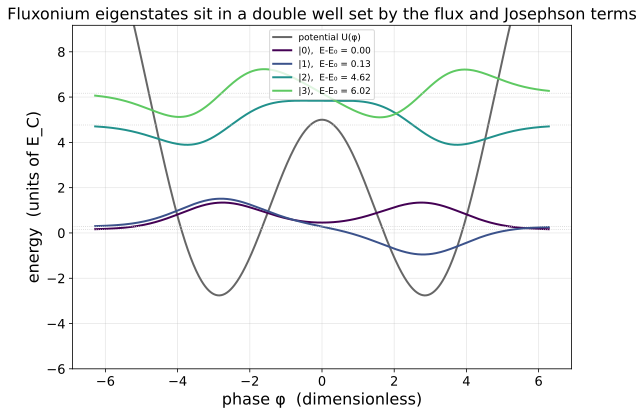

In [13]:
grid = scq.Grid1d(-2*np.pi, 2*np.pi, 500)          # wells sit at +/-2.85, so centre the window on 0
phi_vals = np.linspace(-2*np.pi, 2*np.pi, 500)
U = fluxonium.potential(phi_vals)      # the SAME potential the eigenstates were solved in
esys = fluxonium.eigensys(evals_count=4)
E4 = esys[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(phi_vals, U, color="0.4", lw=2, label="potential U(φ)")
for idx in range(4):
    wf = fluxonium.wavefunction(esys, which=idx, phi_grid=grid)
    ax.plot(wf.basis_labels, 2.5*np.real(wf.amplitudes) + E4[idx], lw=2,
            label=f"|{idx}⟩,  E-E₀ = {E4[idx]-E4[0]:.2f}")
    ax.axhline(E4[idx], color="0.8", lw=0.8, ls=":")
ax.set_xlabel("phase φ  (dimensionless)"); ax.set_ylabel("energy  (units of E_C)")
ax.set_title("Fluxonium eigenstates sit in a double well set by the flux and Josephson terms")
ax.legend(loc="upper center", fontsize=9); ax.set_ylim(-EJ-1, E4[3]+3); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("fig_c2_fluxonium_spectrum.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *The fluxonium potential $U(\varphi)=\tfrac12 E_L\varphi^2-E_J\cos(\varphi+\varphi_{ext})$ at half flux forms a symmetric double well, with minima at $\varphi\approx\pm2.85$ and a barrier of $7.76\,E_C$ at $\varphi=0$. The two lowest states $|0\rangle,|1\rangle$ are a near-degenerate doublet (one symmetric, one antisymmetric across the barrier) — the hallmark of quantum tunneling; the higher states climb the inductive parabola.*

### (c, d) Gaussian wave packets and their dynamics
A **wave packet** localized at $\varphi_0$ is a coherent (Gaussian) state of the fluxonium's LC mode. We evolve it with QuTiP `sesolve` and compare $\langle\hat\varphi\rangle(t),\langle\hat n\rangle(t)$ to the classical trajectory with the same potential.

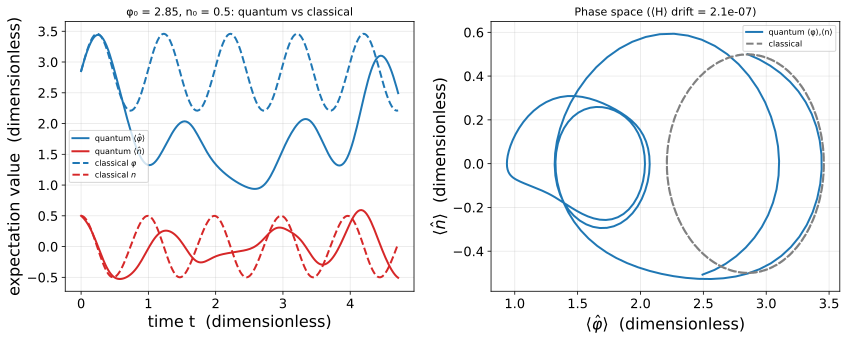

In [14]:
def wave_packet(phi0, n0=0.0):
    '''Gaussian in phi centered at (phi0, n0): a coherent state of the internal LC mode.'''
    alpha = phi0/(2*phi_zpf) + 1j*n0/(2*n_zpf)   # displacement chosen so <phi>=phi0, <n>=n0
    return qt.coherent(DIM, alpha)

T_cl  = 2*np.pi/omega
tlist = np.linspace(0, 1.5*T_cl, 200)            # ~1.5 classical periods

def classical_traj(phi0, n0=0.0):
    '''Classical trajectory in the SAME potential as the fluxonium (canonical equations).'''
    def rhs(t, s):
        ph, nn = s
        # dphi/dt = dH/dn = 8 EC n ;  dn/dt = -dU/dphi with U = 1/2 EL phi^2 - EJ cos(phi+phi_ext)
        return [8*EC*nn, -(EL*ph + EJ*np.sin(ph + phi_ext))]
    sol = solve_ivp(rhs, (0, tlist[-1]), [phi0, n0], t_eval=tlist, rtol=1e-9, atol=1e-9)
    return sol.y[0], sol.y[1]

# The well minimum with n0 = 0 is an EQUILIBRIUM: a classical particle placed there never
# moves, which makes for a meaningless comparison. Start at the bottom of the well but give
# it a small kick in charge so the classical point actually orbits.
phi0, n0_kick = phi_min, 0.5
res = qt.sesolve(H_flux, wave_packet(phi0, n0_kick), tlist, e_ops=[phi_op, n_op, H_flux])
phi_q, n_q, H_q = np.real(res.expect[0]), np.real(res.expect[1]), np.real(res.expect[2])
phi_c, n_c = classical_traj(phi0, n0_kick)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(tlist, phi_q, color="#1f77b4", label=r"quantum $\langle\hat\varphi\rangle$")
ax1.plot(tlist, n_q,   color="#d62728", label=r"quantum $\langle\hat n\rangle$")
ax1.plot(tlist, phi_c, color="#1f77b4", ls="--", label=r"classical $\varphi$")
ax1.plot(tlist, n_c,   color="#d62728", ls="--", label=r"classical $n$")
ax1.set_xlabel("time t  (dimensionless)"); ax1.set_ylabel("expectation value  (dimensionless)")
ax1.set_title(f"φ₀ = {phi0:.2f}, n₀ = {n0_kick}: quantum vs classical", fontsize=11); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.plot(phi_q, n_q, color="#1f77b4", lw=2, label="quantum ⟨φ⟩,⟨n⟩")
ax2.plot(phi_c, n_c, color="0.5", lw=2, ls="--", label="classical")
ax2.set_xlabel(r"$\langle\hat\varphi\rangle$  (dimensionless)"); ax2.set_ylabel(r"$\langle\hat n\rangle$  (dimensionless)")
ax2.set_title(f"Phase space (⟨H⟩ drift = {np.ptp(H_q):.1e})", fontsize=11); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("fig_c2_fluxonium_dynamics.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *A Gaussian packet started at the well minimum $\varphi_0\approx2.85$ with a small charge kick $n_0=0.5$. The quantum averages (solid) track the classical trajectory (dashed) for roughly the first half-period, then fall behind. The reason is Ehrenfest's theorem and its condition: $d\langle\hat n\rangle/dt=\langle-\partial U/\partial\varphi\rangle$, the average of the force — which equals the classical force at the average position only if the force is linear. Here it contains $\sin\hat\varphi$, and $\langle\sin\hat\varphi\rangle\neq\sin\langle\hat\varphi\rangle$, so these averages obey no classical equation of motion. With $\varphi_{zpf}=1.41$ against a well a few radians wide, the packet samples enough curvature for the discrepancy to be large. $\langle\hat H\rangle$ is conserved to $\sim2\times10^{-7}$, so this is physics rather than solver error.*

> **Why the kick?** Placed at the well minimum with $n_0=0$ the classical particle sits at an **equilibrium point** and never moves at all, which makes for a meaningless comparison. The small initial charge sets it orbiting.

### (e, f) Sweep over $\varphi_0$
We repeat for packet centres running from one well, over the barrier, to the other: $\varphi_0\in\{-2.85,\,-1.43,\,0,\,1.43,\,2.85\}$ (the same $n_0$ kick throughout, so no panel sits on a fixed point). Top row: the initial packet over the potential. Bottom row: quantum $\langle\hat\varphi\rangle,\langle\hat n\rangle$ (solid) vs the classical trajectory (dashed).

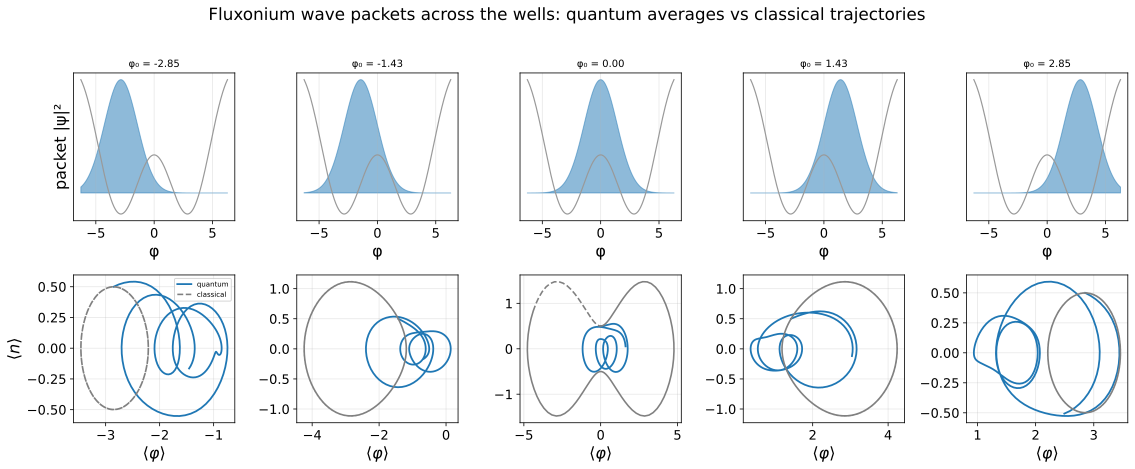

In [15]:
# Walk from the left well, over the barrier at phi = 0, to the right well.
phi0_list = [-phi_min, -phi_min/2, 0.0, phi_min/2, phi_min]
phi_grid_vals = np.linspace(-2*np.pi, 2*np.pi, 400)
U_vals = fluxonium.potential(phi_grid_vals)

fig, axes = plt.subplots(2, len(phi0_list), figsize=(16, 6.5))
for col, phi0 in enumerate(phi0_list):
    # top: initial packet density (Gaussian of width phi_zpf) over the scaled potential
    rho = np.exp(-(phi_grid_vals - phi0)**2 / (2*phi_zpf**2))
    axt = axes[0, col]
    axt.plot(phi_grid_vals, U_vals/np.max(np.abs(U_vals)), color="0.6", lw=1.2)
    axt.fill_between(phi_grid_vals, rho, color="#1f77b4", alpha=0.5)
    axt.set_title(f"φ₀ = {phi0:.2f}", fontsize=10); axt.set_xlabel("φ"); axt.set_yticks([])
    # bottom: quantum vs classical phase space
    r = qt.sesolve(H_flux, wave_packet(phi0, n0_kick), tlist, e_ops=[phi_op, n_op])
    pc, nc = classical_traj(phi0, n0_kick)          # same kick, so no panel sits on a fixed point
    axb = axes[1, col]
    axb.plot(np.real(r.expect[0]), np.real(r.expect[1]), color="#1f77b4", lw=1.8, label="quantum")
    axb.plot(pc, nc, color="0.5", ls="--", lw=1.6, label="classical")
    axb.set_xlabel(r"$\langle\varphi\rangle$"); axb.grid(True, alpha=0.3)
    if col == 0:
        axb.set_ylabel(r"$\langle n\rangle$"); axb.legend(fontsize=7)
axes[0, 0].set_ylabel("packet |ψ|²")
fig.suptitle("Fluxonium wave packets across the wells: quantum averages vs classical trajectories", y=1.01)
plt.tight_layout(); plt.savefig("fig_c2_fluxonium_sweep.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *Packet centre swept across the double well. In the well minima ($\varphi_0=\pm2.85$) the quantum average stays closest to the classical path. Launched on the **barrier top** ($\varphi_0=0$) the classical point sweeps a wide figure-eight across both wells while the quantum packet splits and stays put — the two descriptions disagree completely. This is exactly the classical-vs-quantum boundary the ML model (Component 3) is meant to learn.*

---
## Component 2 — Task 3 takeaways
- Built the fluxonium Hamiltonian with **scqubits**; the low spectrum is a tunneling doublet in a double well.
- Evolved Gaussian wave packets with **QuTiP `sesolve`**; energy is conserved to ~$10^{-7}$.
- Quantum averages track the classical trajectory for about half a period near a well minimum and diverge completely on the barrier — the interesting regime for classical→quantum prediction. The gap never fully closes here: at $E_J/E_C=5$ the packet is as wide as the well, so a coherent state is not a classical point particle anywhere in this regime.
- These $\langle\hat\varphi\rangle(t),\langle\hat n\rangle(t)$ trajectories are the **quantum targets** for Component 3.